In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_roc_curves_with_variability(cell_type, cell_name):
    base_dirs = {
        'Combined': f'/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_both_new/{cell_type}',
        'Genes': f'/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new/{cell_type}',
        'Demo + APOE': f'/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_demo_new/{cell_type}',
        'APOE + Genes': f'/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_apoe_new/{cell_type}',
    }

    colors = {
        'Combined': 'black',
        'Genes': 'blue',
        'Demo + APOE': '#66c2a5',
        'APOE + Genes': 'red',
    }

    plt.figure(figsize=(8, 6))
    mean_fpr = np.linspace(0, 1, 100)

    for label, base_path in base_dirs.items():
        all_tprs = []
        aucs = []

        for i in range(1, 6):
            pred_file = os.path.join(base_path, f'split_{i}', 'test_predictions.csv')
            if not os.path.exists(pred_file):
                print(f"Missing: {label} | Split {i} | Path: {pred_file}")
                continue

            df = pd.read_csv(pred_file)
            y_true = df['true_label']
            y_score = df['predicted_proba']
            fpr, tpr, _ = roc_curve(y_true, y_score)
            interp_tpr = np.interp(mean_fpr, fpr, tpr)
            interp_tpr[0] = 0.0
            all_tprs.append(interp_tpr)
            aucs.append(auc(fpr, tpr))

            plt.plot(fpr, tpr, color=colors[label], alpha=0.2)

        if all_tprs:
            mean_tpr = np.mean(all_tprs, axis=0)
            mean_auc = np.mean(aucs)
            std_auc = np.std(aucs)
            plt.plot(mean_fpr, mean_tpr, color=colors[label], linewidth=2.5,
                     label=f'{label} (AUC: {mean_auc:.3f} ± {std_auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
    plt.title(cell_name, fontsize=16, fontweight='bold')
    plt.xticks(fontsize=12, fontweight='bold')
    plt.yticks(fontsize=12, fontweight='bold')
    plt.legend(loc='lower right', fontsize=11, frameon=True)
    plt.grid(alpha=0.3)
    plt.tight_layout()

    # Save figure
    save_dir = f"/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure2"
    os.makedirs(save_dir, exist_ok=True)
    output_path = os.path.join(save_dir, f'{cell_type}_roc_curve.png')
    plt.savefig(output_path, dpi=300)
    plt.show()

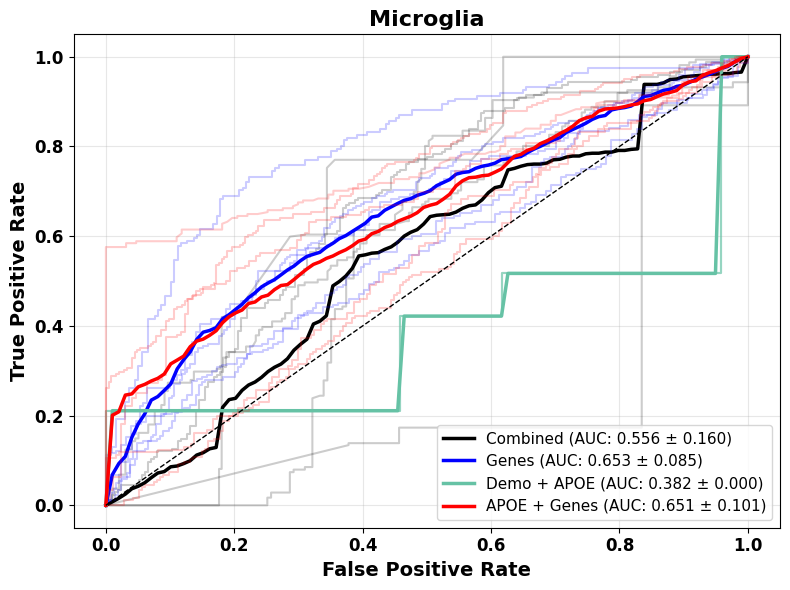

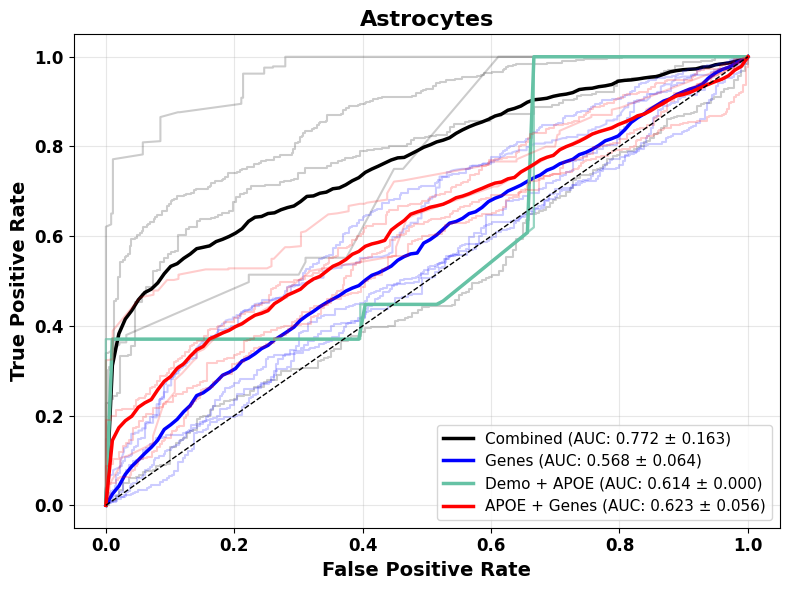

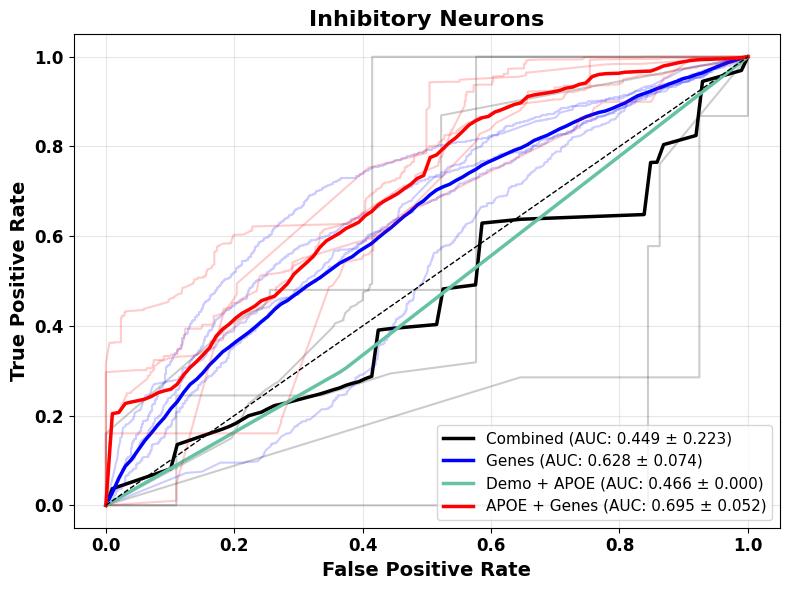

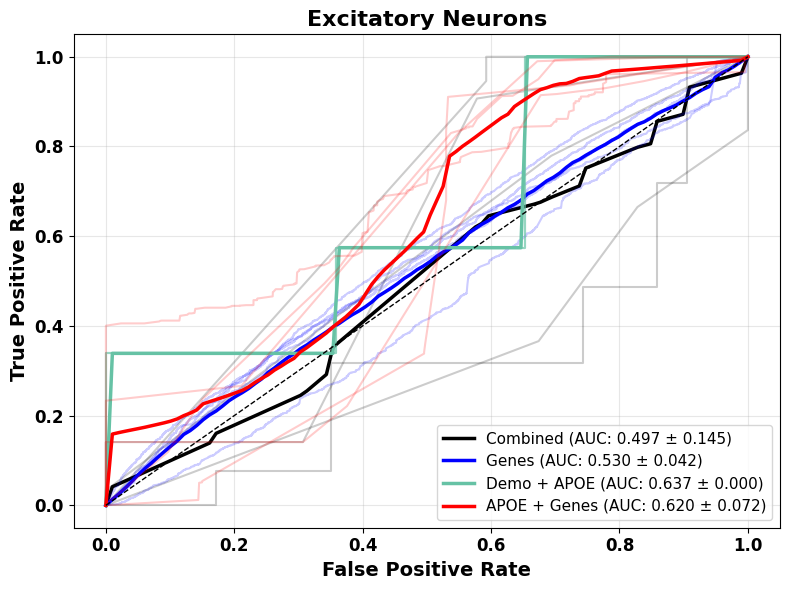

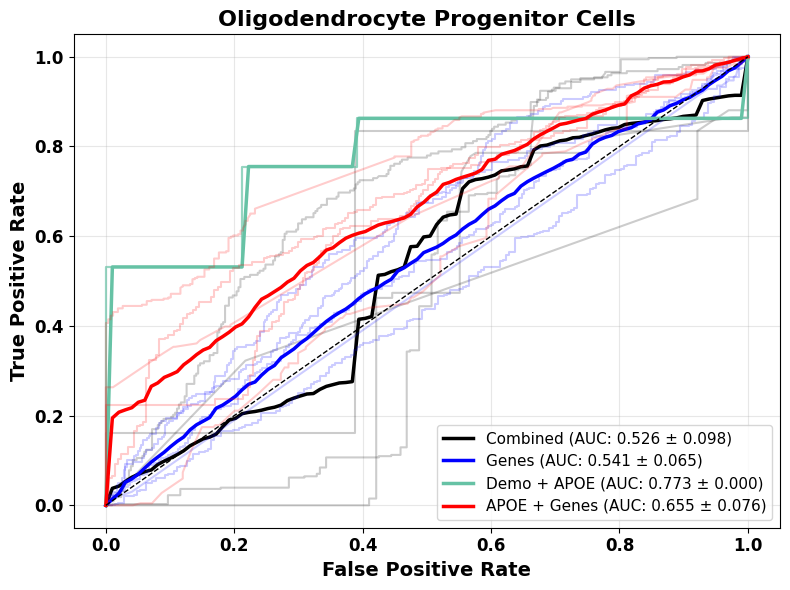

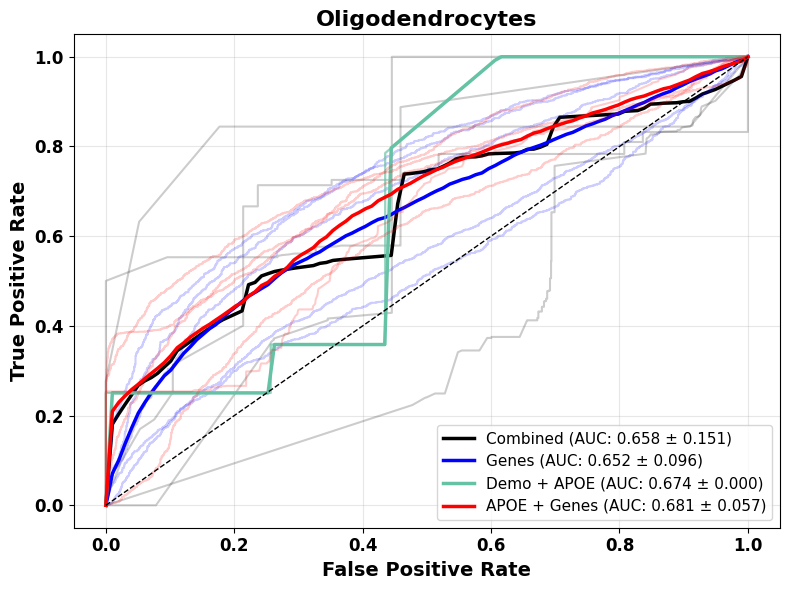

In [3]:
plot_roc_curves_with_variability('Mic', 'Microglia')
plot_roc_curves_with_variability('Ast', 'Astrocytes')
plot_roc_curves_with_variability('In', 'Inhibitory Neurons')
plot_roc_curves_with_variability('Ex', 'Excitatory Neurons')
plot_roc_curves_with_variability('Opc', 'Oligodendrocyte Progenitor Cells')
plot_roc_curves_with_variability('Oli', 'Oligodendrocytes')

Processing: Ast


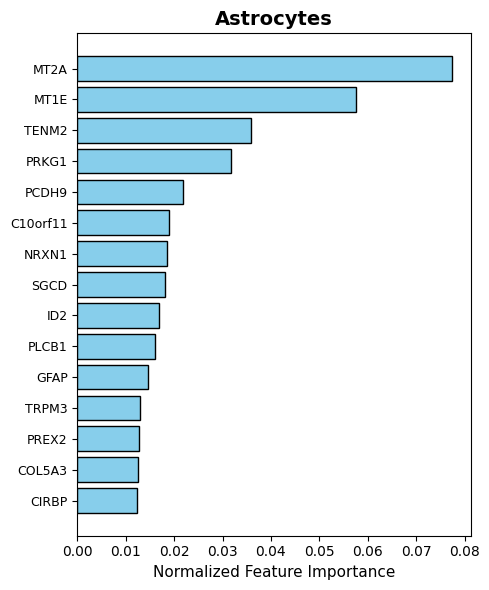

Saved plot for: Astrocytes
Processing: Mic


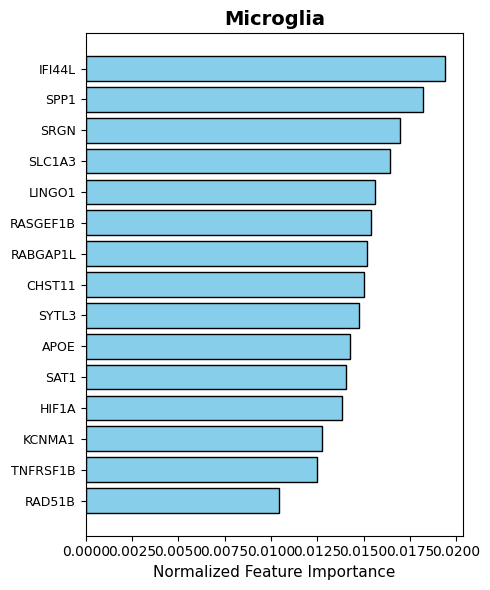

Saved plot for: Microglia
Processing: In


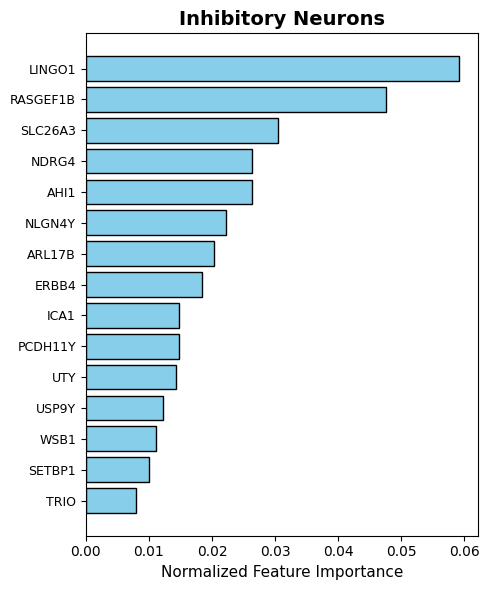

Saved plot for: Inhibitory Neurons
Processing: Oli


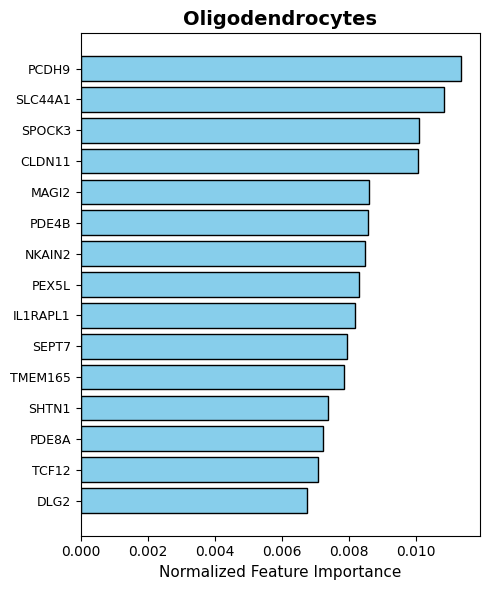

Saved plot for: Oligodendrocytes
Processing: Opc


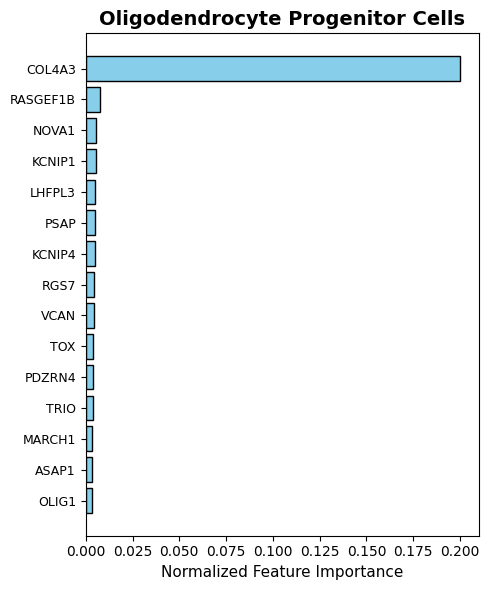

Saved plot for: Oligodendrocyte Progenitor Cells
Processing: Ex


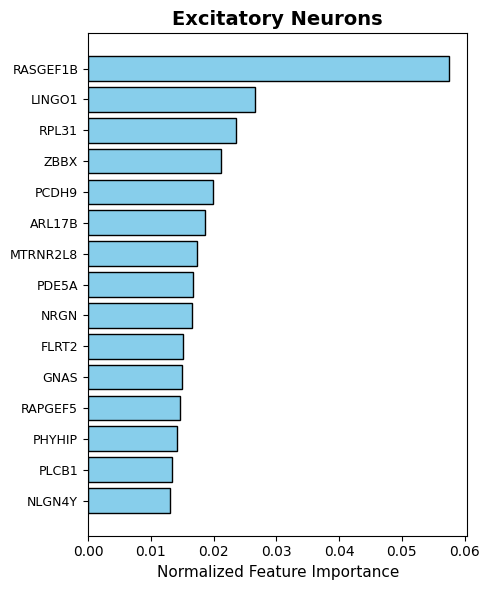

Saved plot for: Excitatory Neurons
 All plots finished and saved!


In [3]:
import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

# === Paths ===
base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new"
output_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure2/FeatureImportancePlots"
os.makedirs(output_dir, exist_ok=True)

# === Cell type labels ===
ct_labels = {
    # 'Ast': 'Astrocytes',
     'Mic': 'Microglia',
#     'In': 'Inhibitory Neurons',
#     'Oli': 'Oligodendrocytes',
#     'Opc': 'Oligodendrocyte Progenitor Cells',
#     'Ex': 'Excitatory Neurons'
# }
cell_types = list(ct_labels.keys())

# === Plotting function ===
def plot_feature_importance(features_df, cell_name, top_n=15):
    df_sorted = features_df.sort_values(by="Filtered_Mean", ascending=False).head(top_n)

    genes = df_sorted["Feature"]
    means = df_sorted["Filtered_Mean"]
    stds = df_sorted["Filtered_Std"]

    plt.figure(figsize=(5, 6))
    plt.barh(range(top_n), means, color="skyblue", edgecolor="black")
    #plt.barh(range(top_n), means, xerr=stds, color="skyblue", edgecolor="black")
    plt.yticks(range(top_n), genes, fontsize=9)
    plt.xlabel("Normalized Feature Importance", fontsize=11)
    plt.title(cell_name, fontsize=14, fontweight="bold")
    plt.gca().invert_yaxis()  # most important on top
    plt.tight_layout()

    save_path = os.path.join(output_dir, f"{cell_name.replace(' ', '_')}_feature_importance.png")
    plt.savefig(save_path, dpi=300)
    plt.show()

    print(f"Saved plot for: {cell_name}")

# === Main loop ===
for cell_type in cell_types:
    print(f"Processing: {cell_type}")
    all_split_data = {}
    all_features = set()

    for split in range(1, 6):
        joblib_path = os.path.join(base_dir, cell_type, f"split_{split}", "maximal_classifier.joblib")
        if not os.path.exists(joblib_path):
            print(f"  Warning: Split {split} for {cell_type} is missing!")
            all_split_data[split] = {}
            continue

        model = joblib.load(joblib_path)
        feature_names = model.feature_names_in_
        importances = model.feature_importances_

        all_features.update(feature_names)
        all_split_data[split] = dict(zip(feature_names, importances))

    # Build dataframe rows
    table_rows = []
    sorted_features = sorted(list(all_features))

    for feature in sorted_features:
        raw_values = []
        filtered_norm_values = []

        for split in range(1, 6):
            raw_imp = all_split_data.get(split, {}).get(feature, 0.0)
            raw_values.append(raw_imp)

            all_imps_in_split = np.array(list(all_split_data.get(split, {}).values()))
            total_nonzero_imp = np.nansum(all_imps_in_split[all_imps_in_split > 0])

            if raw_imp > 0 and total_nonzero_imp > 0:
                norm_imp = raw_imp / total_nonzero_imp
            else:
                norm_imp = 0.0

            filtered_norm_values.append(norm_imp)

        filtered_mean = np.mean(filtered_norm_values)
        
        filtered_std = np.std(filtered_norm_values) / np.sqrt(len(filtered_norm_values))  # Use SEM instead of SD
        # filtered_std = np.std(filtered_norm_values)

        # Add to final row
        row_data = {
            "Feature": feature,
            "Filtered_Mean": filtered_mean,
            "Filtered_Std": filtered_std
        }
        table_rows.append(row_data)

    # Convert to dataframe
    features_df = pd.DataFrame(table_rows)

    # Plot
    plot_feature_importance(features_df, ct_labels[cell_type])

print(" All plots finished and saved!")

In [4]:
import os
import joblib
import numpy as np

# === Paths ===
base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new"

# === Cell type labels ===
ct_labels = {
    'Ast': 'Astrocytes',
    #'Mic': 'Microglia',
    'In': 'Inhibitory Neurons',
    #'Oli': 'Oligodendrocytes',
    #'Opc': 'Oligodendrocyte Progenitor Cells',
    'Ex': 'Excitatory Neurons'
}
cell_types = list(ct_labels.keys())

# === Gene of interest ===
gene_of_interest = "RASGEF1B"

# === Check and print ===
print(f"=== Checking predictor status for: {gene_of_interest} ===\n")

for cell_type in cell_types:
    non_zero_count = 0
    split_values = []

    for split in range(1, 6):
        joblib_path = os.path.join(base_dir, cell_type, f"split_{split}", "maximal_classifier.joblib")
        if not os.path.exists(joblib_path):
            split_values.append(None)
            continue

        model = joblib.load(joblib_path)
        feature_names = model.feature_names_in_
        importances = model.feature_importances_

        feature_dict = dict(zip(feature_names, importances))
        raw_imp = feature_dict.get(gene_of_interest, 0.0)

        # Normalize within this split
        nonzero_total = np.sum([v for v in feature_dict.values() if v > 0])
        norm_imp = raw_imp / nonzero_total if raw_imp > 0 and nonzero_total > 0 else 0.0

        if norm_imp > 0:
            non_zero_count += 1
        split_values.append(norm_imp)

    print(f"{ct_labels[cell_type]}:")
    for i, val in enumerate(split_values, start=1):
        if val is None:
            print(f"  Split {i}: MISSING")
        else:
            print(f"  Split {i}: {val:.6f}")
    print(f"  --> Non-zero in {non_zero_count}/5 splits\n")

print("Check complete.")

=== Checking predictor status for: RASGEF1B ===

Astrocytes:
  Split 1: 0.007407
  Split 2: 0.000000
  Split 3: 0.000000
  Split 4: 0.000000
  Split 5: 0.000000
  --> Non-zero in 1/5 splits

Inhibitory Neurons:
  Split 1: 0.035176
  Split 2: 0.000640
  Split 3: 0.000000
  Split 4: 0.035714
  Split 5: 0.166667
  --> Non-zero in 4/5 splits

Excitatory Neurons:
  Split 1: 0.099490
  Split 2: 0.045699
  Split 3: 0.052632
  Split 4: 0.033898
  Split 5: 0.056122
  --> Non-zero in 5/5 splits

Check complete.


/tmp/ipykernel_4013565/529686007.py:73: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = pd.DataFrame(index=list(all_features), columns=list(cell_types.values())).fillna(0)
/tmp/ipykernel_4013565/529686007.py:76: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.006345616184462664' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[feat, cell] = val
/tmp/ipykernel_4013565/529686007.py:76: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.357315233785822' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[feat, cell] = va

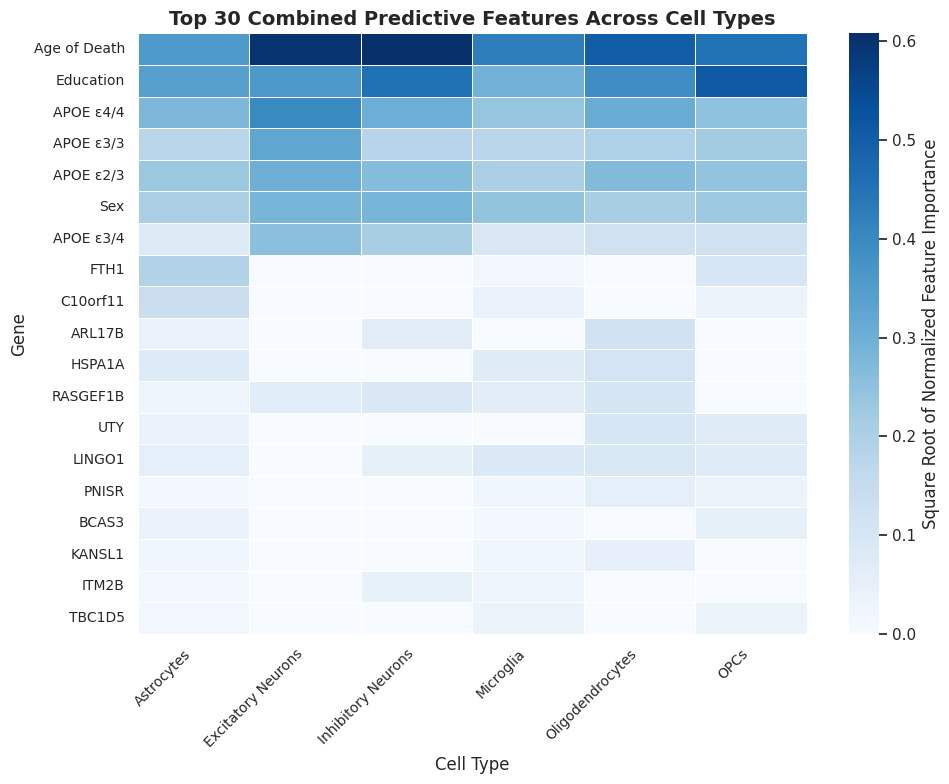

In [12]:
import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

# Set paths
model_base_path = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_both_new"
save_path = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure2/feature_importance_heatmap_top30_genes_both.png"


# Pretty cell type labels
cell_types = {
    "Ast": "Astrocytes",
    "Ex": "Excitatory Neurons",
    "In": "Inhibitory Neurons",
    "Mic": "Microglia",
    "Oli": "Oligodendrocytes",
    "Opc": "OPCs"
}

# Feature renaming dictionary
pretty_names = {
    "age_death": "Age of Death",
    "educ": "Education",
    "msex": "Sex",
    "apoe_genotype_230": "APOE ε2/3",
    "apoe_genotype_330": "APOE ε3/3",
    "apoe_genotype_340": "APOE ε3/4",
    "apoe_genotype_440": "APOE ε4/4",
}

# Step 1: Collect importances per cell type
importance_dict = {}

for short, pretty in cell_types.items():
    feature_data = defaultdict(list)
    missing_splits = []
    for i in range(1, 6):
        model_path = os.path.join(model_base_path, short, f'split_{i}', 'maximal_classifier.joblib')
        if not os.path.exists(model_path):
            continue

        model = joblib.load(model_path)
        feature_names = np.array(model.feature_names_in_)
        importances = model.feature_importances_

        nonzero_mask = importances != 0
        feature_names = feature_names[nonzero_mask]
        importances = importances[nonzero_mask]
        normalized = importances / np.sum(importances)

        for feat, score in zip(feature_names, normalized):
            feature_data[feat].append(score)
    if missing_splits:
        print(f"Missing splits for {pretty} ({short}): {missing_splits}")

    # Pad each feature's list to length 5 (adding zeros if feature not present in some splits)
    for feat in feature_data:
        while len(feature_data[feat]) < 5:
            feature_data[feat].append(0.0)

    mean_importances = {feat: np.mean(vals) for feat, vals in feature_data.items()}
    importance_dict[pretty] = mean_importances

# Step 2: Construct DataFrame
all_features = set()
for cell_imp in importance_dict.values():
    all_features.update(cell_imp.keys())

df = pd.DataFrame(index=list(all_features), columns=list(cell_types.values())).fillna(0)
for cell, feats in importance_dict.items():
    for feat, val in feats.items():
        df.loc[feat, cell] = val

# Step 3: Pick top 20 features (by max importance in any cell type)
# Step 3: Filter features present (non-zero) in at least 2 different cell types
nonzero_counts = (df > 0).sum(axis=1)
df_filtered = df[nonzero_counts >= 1]

# Now pick top 30 based on max importance across cell types
top_30_feats = df_filtered.max(axis=1).nlargest(30).index
df_top20 = df_filtered.loc[top_30_feats]
# For visual understanding
df_top20 = np.sqrt(df_top20)

# Step 4: Rename features for clarity
df_top20.index = [pretty_names.get(f, f) for f in df_top20.index]

# Step 5: Plot
plt.figure(figsize=(10, 8))
sns.set(style="whitegrid")

ax = sns.heatmap(df_top20, cmap="Blues", linewidths=0.5,
                 cbar_kws={"label": "Square Root of Normalized Feature Importance"},
                 xticklabels=True, yticklabels=True)

plt.title("Top Combined Predictive Features Across Cell Types", fontsize=14, fontweight='bold')
plt.xlabel("Cell Type", fontsize=12)
plt.ylabel("Gene", fontsize=12)
plt.xticks(fontsize=10, rotation=45, ha="right")
plt.yticks(fontsize=10)
plt.tight_layout()

# Save clean version
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=600, bbox_inches="tight")
plt.show()

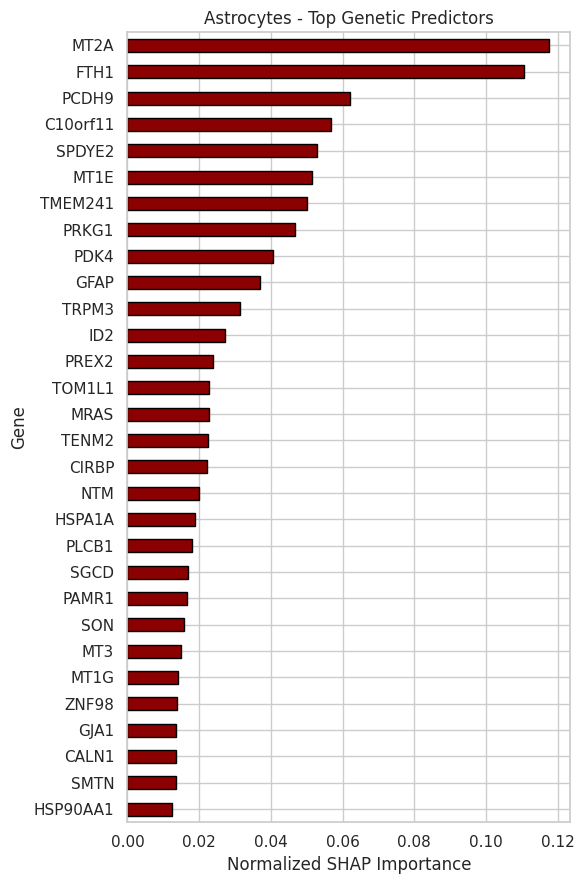

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure2/New_Feature_Importance/Combined_model_GeneOnly_Barplots/Astrocytes_gene_SHAP_barplot.png


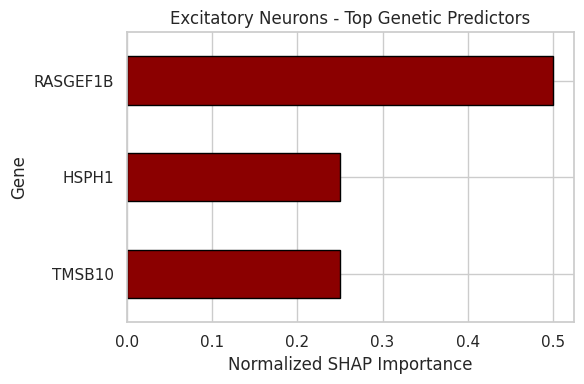

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure2/New_Feature_Importance/Combined_model_GeneOnly_Barplots/Excitatory Neurons_gene_SHAP_barplot.png


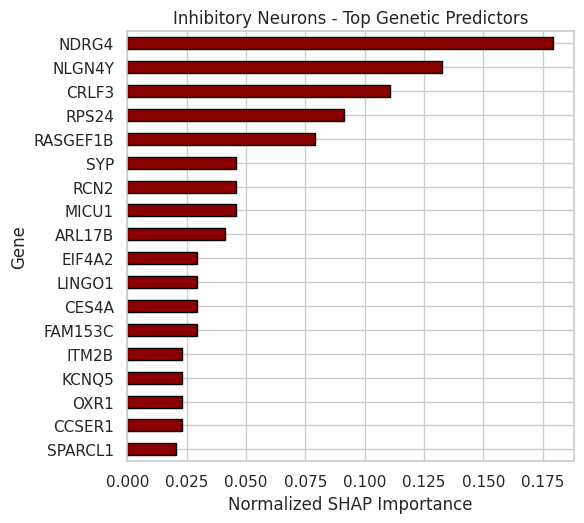

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure2/New_Feature_Importance/Combined_model_GeneOnly_Barplots/Inhibitory Neurons_gene_SHAP_barplot.png


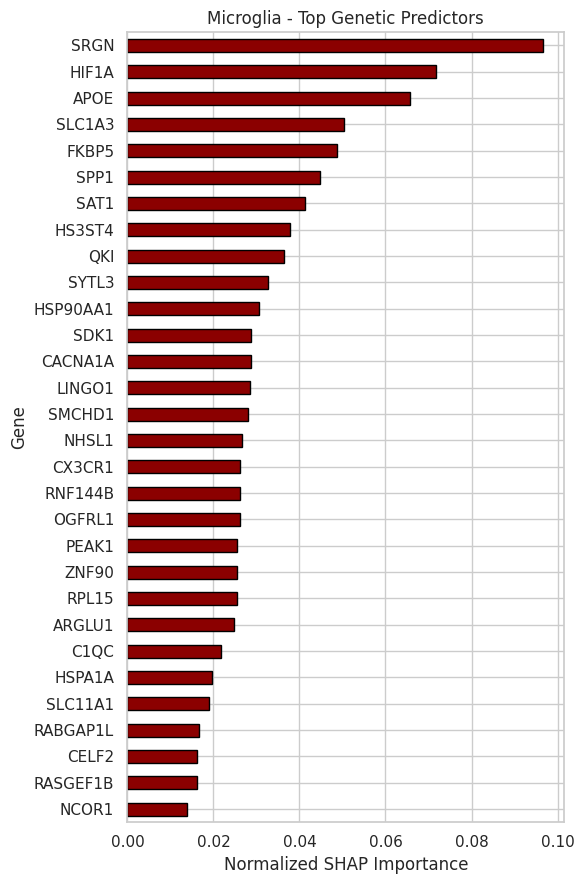

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure2/New_Feature_Importance/Combined_model_GeneOnly_Barplots/Microglia_gene_SHAP_barplot.png


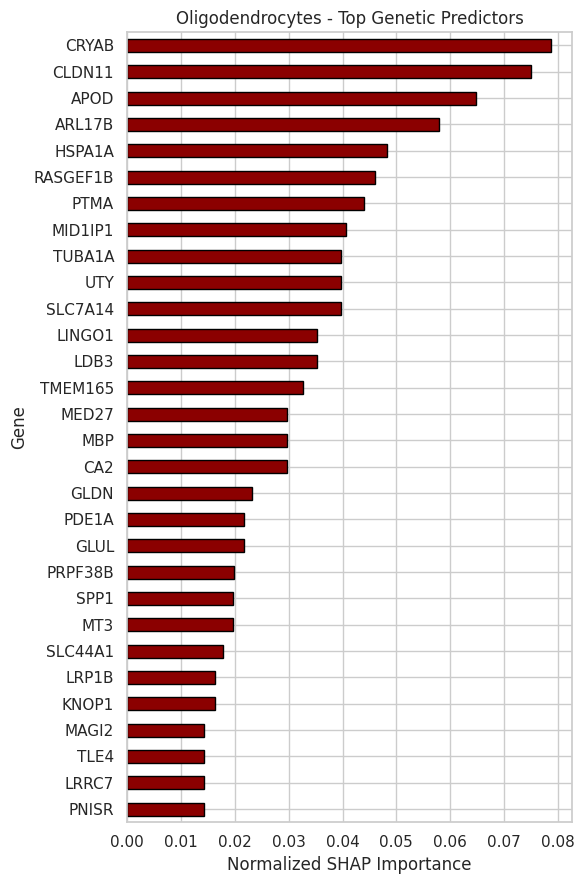

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure2/New_Feature_Importance/Combined_model_GeneOnly_Barplots/Oligodendrocytes_gene_SHAP_barplot.png


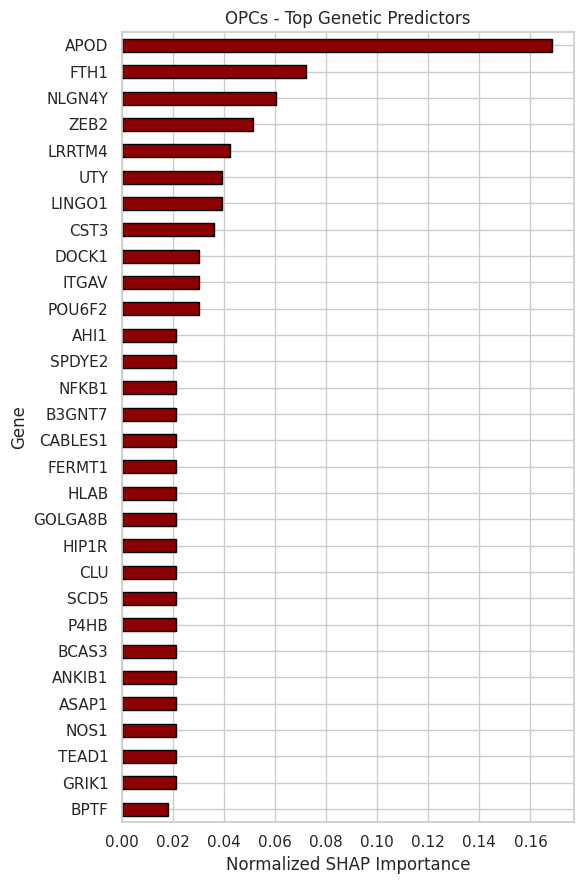

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure2/New_Feature_Importance/Combined_model_GeneOnly_Barplots/OPCs_gene_SHAP_barplot.png


In [6]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

# === Set paths ===
model_base_path = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_both_new"
output_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure2/New_Feature_Importance/Combined_model_GeneOnly_Barplots"
os.makedirs(output_dir, exist_ok=True)

# === Cell type labels ===
cell_types = {
    "Ast": "Astrocytes",
    "Ex": "Excitatory Neurons",
    "In": "Inhibitory Neurons",
    "Mic": "Microglia",
    "Oli": "Oligodendrocytes",
    "Opc": "OPCs"
}

# === Features to drop (non-genetic) ===
drop_features = {
    "age_death", "educ", "msex",
    "apoe_genotype_230", "apoe_genotype_240",
    "apoe_genotype_330", "apoe_genotype_340", "apoe_genotype_440"
}

# === Step 1: Collect per-cell-type SHAP importances ===
importance_dict = {}

for short, pretty in cell_types.items():
    feature_data = defaultdict(list)
    for i in range(1, 6):
        model_path = os.path.join(model_base_path, short, f'split_{i}', 'maximal_classifier.joblib')
        if not os.path.exists(model_path):
            continue
        model = joblib.load(model_path)
        feature_names = np.array(model.feature_names_in_)
        importances = model.feature_importances_
        
        nonzero_mask = importances != 0
        feature_names = feature_names[nonzero_mask]
        importances = importances[nonzero_mask]
        
        # Normalize within split
        normalized = importances / np.sum(importances)
        
        for feat, score in zip(feature_names, normalized):
            if feat not in drop_features:
                feature_data[feat].append(score)
    
    # Pad to length 5
    for feat in feature_data:
        while len(feature_data[feat]) < 5:
            feature_data[feat].append(0.0)
    
    mean_importances = {feat: np.mean(vals) for feat, vals in feature_data.items()}
    importance_dict[pretty] = mean_importances

# === Step 2: Plot per cell type ===
for cell_type, gene_dict in importance_dict.items():
    # Convert to Series, sort ascending
    gene_series = pd.Series(gene_dict).sort_values(ascending=True)
    
    # Optional: take top N
    top_n = 30
    gene_series = gene_series.tail(top_n)
    
    # Normalize within cell type (optional but often helpful for visual clarity)
    gene_series /= gene_series.sum()
    
    # Plot
    plt.figure(figsize=(6, max(4, len(gene_series) * 0.3)))
    gene_series.plot(kind='barh', color='darkred', edgecolor='black')
    plt.xlabel("Normalized SHAP Importance")
    plt.ylabel("Gene")
    plt.title(f"{cell_type} - Top Genetic Predictors")
    plt.tight_layout()
    
    # Save
    plot_path = os.path.join(output_dir, f"{cell_type}_gene_SHAP_barplot.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"Saved: {plot_path}")

/tmp/ipykernel_3514015/678059051.py:67: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = pd.DataFrame(index=sorted(all_features), columns=list(cell_types.values())).fillna(0)
/tmp/ipykernel_3514015/678059051.py:70: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.041940391570021204' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[feat, cell] = val
/tmp/ipykernel_3514015/678059051.py:70: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.08253393665158372' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[feat, cell] 

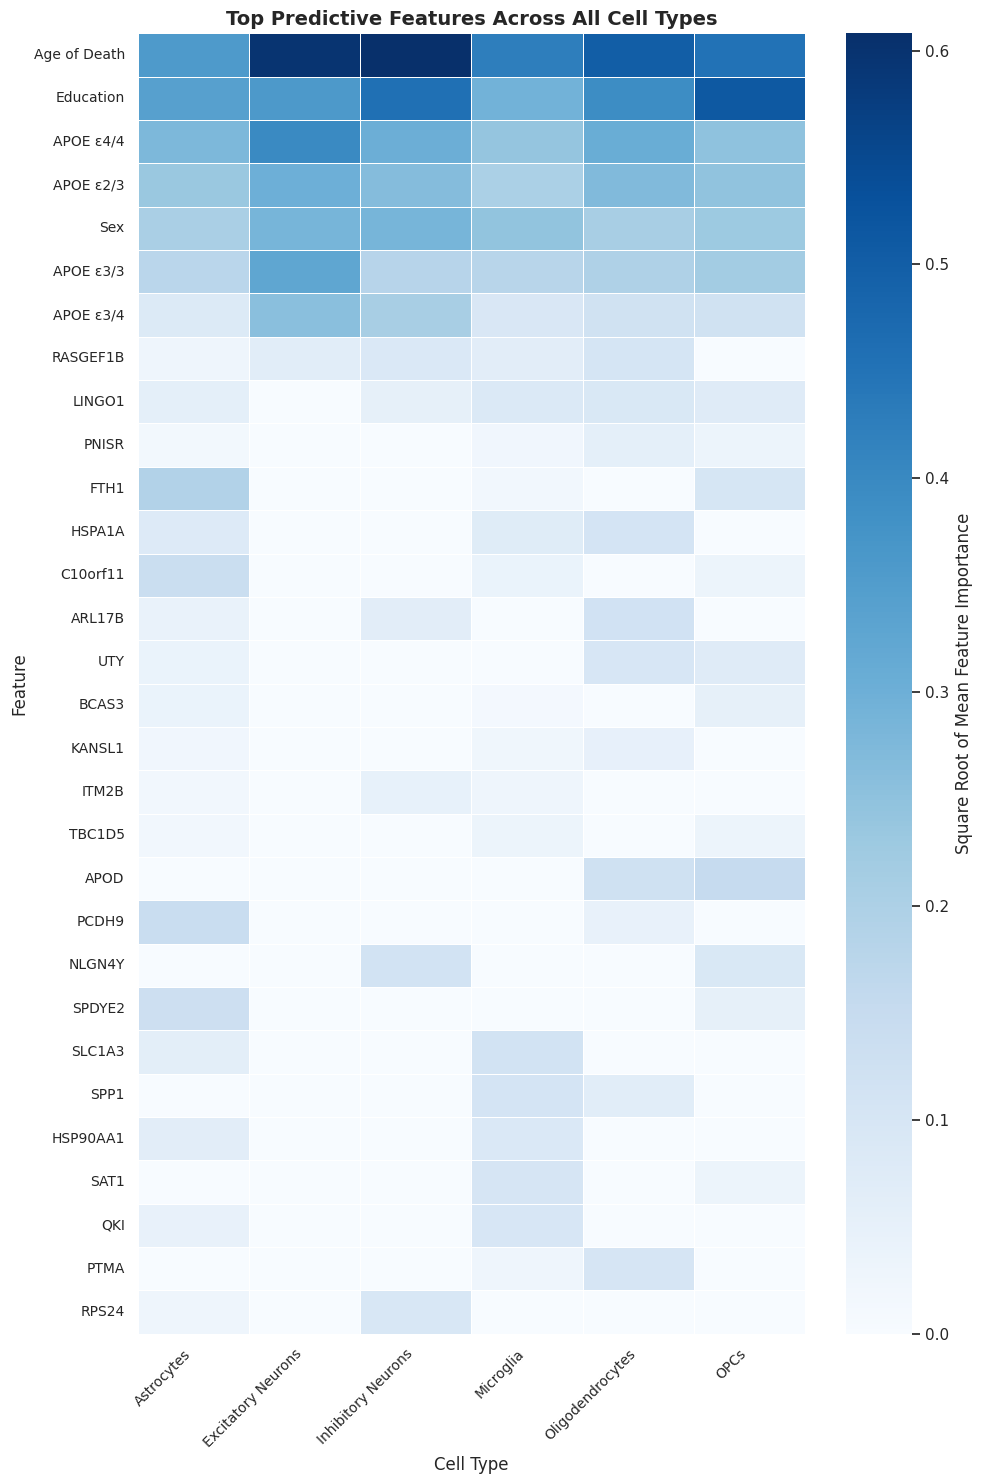

 Heatmap saved to: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure2/New_Feature_Importance/feature_importance_heatmap_top30_allfeatures.png


In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# === Paths ===
model_base_path = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_both_new"
heatmap_output = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure2/New_Feature_Importance/feature_importance_heatmap_top30_allfeatures.png"
os.makedirs(os.path.dirname(heatmap_output), exist_ok=True)

# === Cell types ===
cell_types = {
    "Ast": "Astrocytes",
    "Ex": "Excitatory Neurons",
    "In": "Inhibitory Neurons",
    "Mic": "Microglia",
    "Oli": "Oligodendrocytes",
    "Opc": "OPCs"
}

# === Pretty feature names ===
pretty_names = {
    "age_death": "Age of Death",
    "educ": "Education",
    "msex": "Sex",
    "apoe_genotype_230": "APOE ε2/3",
    "apoe_genotype_240": "APOE ε2/4",
    "apoe_genotype_330": "APOE ε3/3",
    "apoe_genotype_340": "APOE ε3/4",
    "apoe_genotype_440": "APOE ε4/4",
}

# === Step 1: Collect importances
importance_dict = {}

for short, pretty_label in cell_types.items():
    feature_data = defaultdict(list)
    for i in range(1, 6):
        model_path = os.path.join(model_base_path, short, f"split_{i}", "maximal_classifier.joblib")
        if not os.path.exists(model_path):
            continue
        model = joblib.load(model_path)
        feature_names = model.feature_names_in_
        importances = model.feature_importances_
        importances = importances / np.sum(importances)

        for feat, val in zip(feature_names, importances):
            feature_data[feat].append(val)

    # Pad all feature lists to length 5
    for feat in feature_data:
        while len(feature_data[feat]) < 5:
            feature_data[feat].append(0.0)

    # Compute mean per feature
    mean_importances = {feat: np.mean(vals) for feat, vals in feature_data.items()}
    importance_dict[pretty_label] = mean_importances

# === Step 2: Construct raw importance matrix (features × cell types)
all_features = set()
for cell_dict in importance_dict.values():
    all_features.update(cell_dict.keys())

df = pd.DataFrame(index=sorted(all_features), columns=list(cell_types.values())).fillna(0)
for cell, feature_scores in importance_dict.items():
    for feat, val in feature_scores.items():
        df.loc[feat, cell] = val

# === Step 3: Rank features by number of predictive cell types (then global mean)
nonzero_counts = (df > 0).sum(axis=1)        # in how many cell types is this feature nonzero?
global_means = df.mean(axis=1)               # global mean (divide by 6)

ranking_df = pd.DataFrame({
    "Feature": df.index,
    "NonzeroCount": nonzero_counts,
    "GlobalMean": global_means
})

# Sort: primary = more predictive cell types; secondary = higher global mean
ranking_df = ranking_df.sort_values(by=["NonzeroCount", "GlobalMean"], ascending=[False, False])
top_features = ranking_df["Feature"].head(30)

# === Step 4: Prepare data for heatmap
df_top = df.loc[top_features]
df_top_pretty = df_top.copy()
df_top_pretty.index = [pretty_names.get(f, f) for f in df_top.index]

# === Step 5: Plot heatmap using square root scale
sqrt_df = np.sqrt(df_top_pretty)

plt.figure(figsize=(10, 0.5 * len(sqrt_df)))
sns.set(style="whitegrid")
ax = sns.heatmap(
    sqrt_df,
    cmap="Blues",
    linewidths=0.5,
    annot=False,
    fmt=".3f",
    cbar_kws={"label": "Square Root of Mean Feature Importance"},
    xticklabels=True,
    yticklabels=True
)

plt.title("Top Predictive Features Across All Cell Types", fontsize=14, fontweight='bold')
plt.xlabel("Cell Type", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.xticks(fontsize=10, rotation=45, ha="right")
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig(heatmap_output, dpi=300)
plt.show()
print(f" Heatmap saved to: {heatmap_output}")

Total background genes: 17926

Running pathway analysis for: Ast


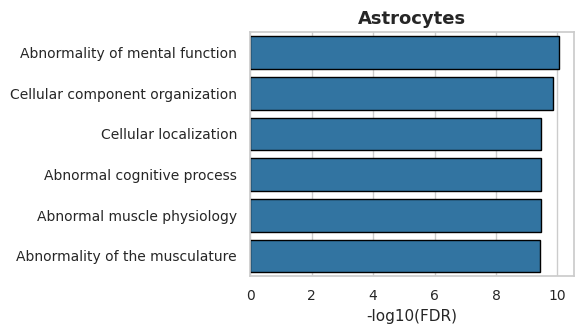

  Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure2/PathwayAnalysis/Ast_pathway_plot.png

Running pathway analysis for: Ex


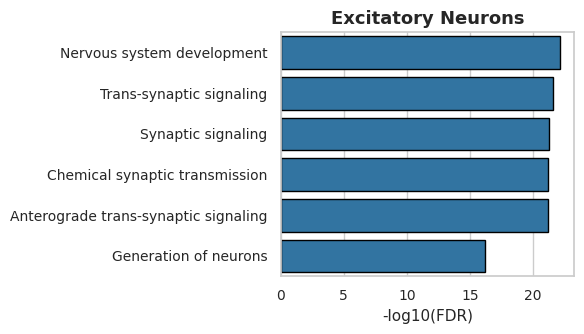

  Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure2/PathwayAnalysis/Ex_pathway_plot.png

Running pathway analysis for: In


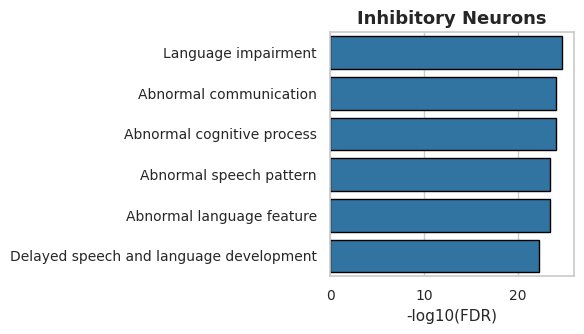

  Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure2/PathwayAnalysis/In_pathway_plot.png

Running pathway analysis for: Mic


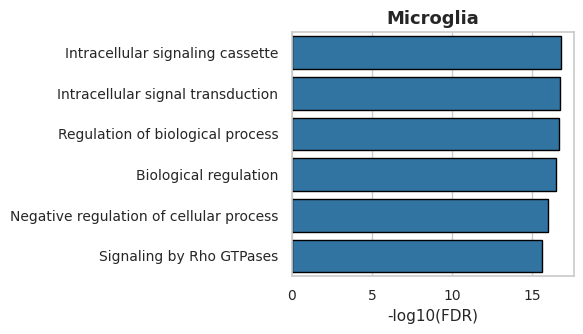

  Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure2/PathwayAnalysis/Mic_pathway_plot.png

Running pathway analysis for: Oli


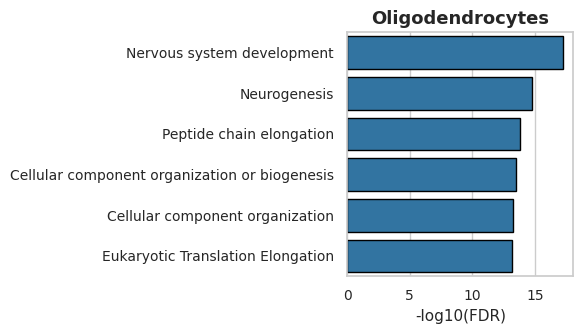

  Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure2/PathwayAnalysis/Oli_pathway_plot.png

Running pathway analysis for: Opc


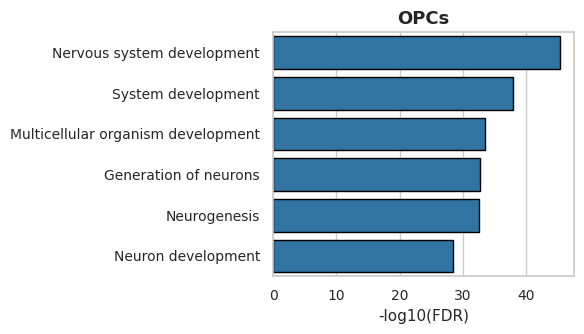

  Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure2/PathwayAnalysis/Opc_pathway_plot.png

Running global enrichment analysis...


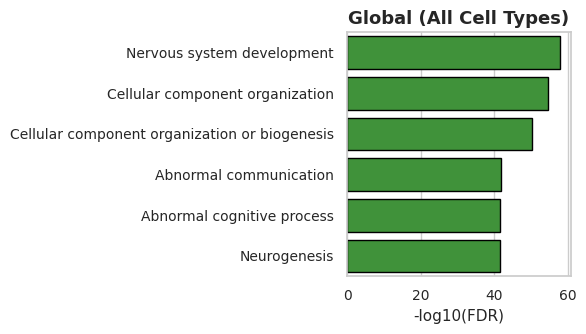

  Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure2/PathwayAnalysis/Global_pathway_plot.png


In [18]:
from gprofiler import GProfiler
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import joblib
from gprofiler import GProfiler

ct_labels = {
    'Ast': 'Astrocytes',
    'Ex': 'Excitatory Neurons',
    'In': 'Inhibitory Neurons',
    'Mic': 'Microglia',
    'Oli': 'Oligodendrocytes',
    'Opc': 'OPCs'
}

# === Paths and setup ===
output_dir = '/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure2/'
pathway_dir = os.path.join(output_dir, "PathwayAnalysis")
os.makedirs(pathway_dir, exist_ok=True)

gp = GProfiler(return_dataframe=True)
global_predictive_genes = set()

# === Load background genes ===
gene_matrix = pd.read_parquet('/home/adm808/NormalizedCellMatrixSyn18485175.parquet')
background_genes = set(gene_matrix.index.str.upper())
print(f"Total background genes: {len(background_genes)}")

# === Predictive gene finder ===
def get_predictive_genes(all_split_data, all_features, min_splits=1):
    predictive_genes = []
    for feature in sorted(all_features):
        nonzero_count = sum(
            all_split_data.get(split, {}).get(feature, 0.0) > 0 for split in range(1, 6)
        )
        if nonzero_count >= min_splits:
            predictive_genes.append(feature.upper())
    return predictive_genes

# === Run gProfiler with background ===
def run_pathway_analysis(gene_list, background_list, organism="hsapiens"):
    return gp.profile(
        organism=organism,
        query=gene_list,
        user_threshold=0.05,
        sources=['GO:BP', 'KEGG', 'REAC', 'WP', 'HP', 'OMIM', 'CORUM'],
        no_evidences=False,
        background=background_list
    )

# === Stylized plot ===
def plot_pathways(df, title, save_path, top_n=6, color="dodgerblue"):
    df = df[~df["name"].str.lower().str.strip().eq("corum root")]
    df = df[df['p_value'] < 0.05].sort_values("p_value").head(top_n)
    if df.empty:
        print(f"  No enriched terms for {title}")
        return
    df["name"] = df["name"].str.replace(r"(^\w+)", lambda m: m.group(1).capitalize(), regex=True)
    
    df["-log10(FDR)"] = -np.log10(df["p_value"])
    df = df.sort_values("-log10(FDR)", ascending=True)

    plt.figure(figsize=(6, 3.5))
    sns.barplot(
        x="-log10(FDR)",
        y="name",
        data=df,
        color=color,
        edgecolor="black"
    )
    plt.title(title, fontsize=13, fontweight="bold")
    plt.xlabel("-log10(FDR)", fontsize=11)
    plt.ylabel("")
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.gca().invert_yaxis()  # Most significant on top
    plt.tight_layout()
    plt.savefig(save_path, dpi=600)
    plt.show()
    print(f"  Saved: {save_path}")

# === Pathway Analysis Loop ===
for cell_type in cell_types:
    print(f"\nRunning pathway analysis for: {cell_type}")
    all_split_data = {}
    all_features = set()

    for split in range(1, 6):
        joblib_path = os.path.join(base_dir, cell_type, f"split_{split}", "maximal_classifier.joblib")
        if not os.path.exists(joblib_path):
            print(f"  Warning: Missing split {split} for {cell_type}")
            all_split_data[split] = {}
            continue

        model = joblib.load(joblib_path)
        feature_names = model.feature_names_in_
        importances = model.feature_importances_

        all_features.update(feature_names)
        all_split_data[split] = dict(zip(feature_names, importances))

    predictive_genes = get_predictive_genes(all_split_data, all_features)
    if len(predictive_genes) < 5:
        print(f"  Too few predictive genes for {cell_type}. Skipping.")
        continue

    global_predictive_genes.update(predictive_genes)

    enrich_df = run_pathway_analysis(predictive_genes, list(background_genes))
    enrich_df.to_csv(os.path.join(pathway_dir, f"{cell_type}_enrichment.csv"), index=False)

    plot_pathways(
        enrich_df,
        title=ct_labels[cell_type],
        save_path=os.path.join(pathway_dir, f"{cell_type}_pathway_plot.png"),
        top_n=6,
        color="#1f78b4"  # Adjust for each cell type if desired
    )

# === Global Pathway Analysis ===
print("\nRunning global enrichment analysis...")
global_predictive_genes = list(global_predictive_genes)
global_enrich_df = run_pathway_analysis(global_predictive_genes, list(background_genes))
global_enrich_df.to_csv(os.path.join(pathway_dir, "Global_enrichment.csv"), index=False)

plot_pathways(
    global_enrich_df,
    title="Global (All Cell Types)",
    save_path=os.path.join(pathway_dir, "Global_pathway_plot.png"),
    top_n=6,
    color="#33a02c"
)

Total background genes: 17926

Running GSEA pathway analysis for: Ast


2025-08-05 20:12:45,066 [WARNING] Duplicated values found in preranked stats: 4.00% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-08-05 20:12:45,082 [INFO] Parsing data files for GSEA.............................
2025-08-05 20:12:45,085 [INFO] Enrichr library gene sets already downloaded in: /home/adm808/.cache/gseapy, use local file
2025-08-05 20:12:45,101 [INFO] 1126 gene_sets have been filtered out when max_size=1000 and min_size=5
2025-08-05 20:12:45,111 [INFO] 0021 gene_sets used for further statistical testing.....
2025-08-05 20:12:45,112 [INFO] Start to run GSEA...Might take a while..................
2025-08-05 20:12:45,174 [INFO] Congratulations. GSEApy runs successfully................



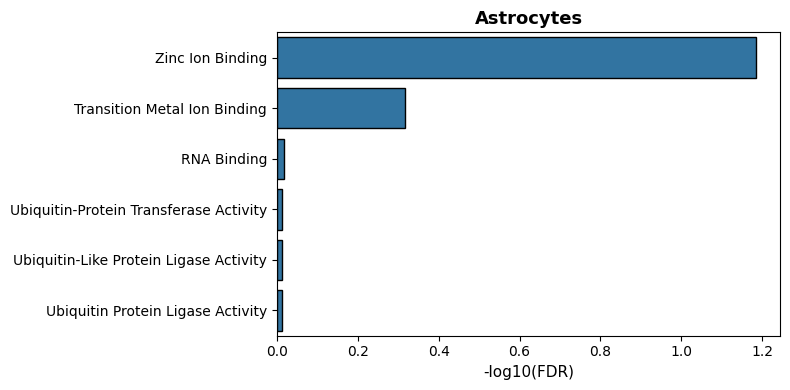

  Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure2/PathwayAnalysis_GSEA/Ast_gsea_plot_filtered.png

Running GSEA pathway analysis for: Ex


2025-08-05 20:12:46,655 [WARNING] Duplicated values found in preranked stats: 41.36% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-08-05 20:12:46,657 [INFO] Parsing data files for GSEA.............................
2025-08-05 20:12:46,658 [INFO] Enrichr library gene sets already downloaded in: /home/adm808/.cache/gseapy, use local file
2025-08-05 20:12:46,676 [INFO] 1127 gene_sets have been filtered out when max_size=1000 and min_size=5
2025-08-05 20:12:46,678 [INFO] 0020 gene_sets used for further statistical testing.....
2025-08-05 20:12:46,679 [INFO] Start to run GSEA...Might take a while..................
2025-08-05 20:12:46,722 [INFO] Congratulations. GSEApy runs successfully................



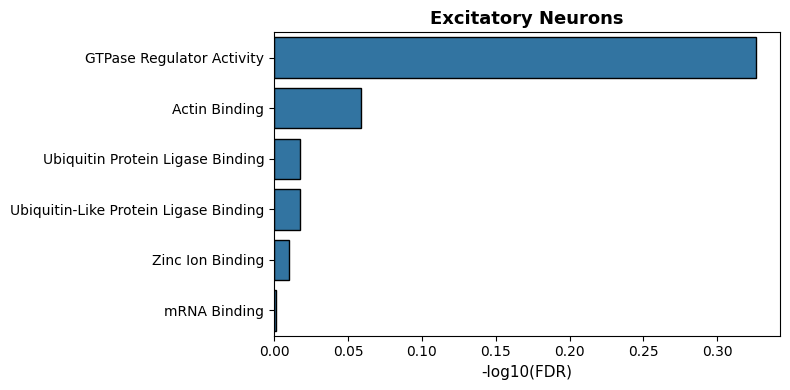

  Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure2/PathwayAnalysis_GSEA/Ex_gsea_plot_filtered.png

Running GSEA pathway analysis for: In


2025-08-05 20:12:47,857 [WARNING] Duplicated values found in preranked stats: 38.89% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-08-05 20:12:47,859 [INFO] Parsing data files for GSEA.............................
2025-08-05 20:12:47,862 [INFO] Enrichr library gene sets already downloaded in: /home/adm808/.cache/gseapy, use local file
2025-08-05 20:12:47,882 [INFO] 1138 gene_sets have been filtered out when max_size=1000 and min_size=5
2025-08-05 20:12:47,883 [INFO] 0009 gene_sets used for further statistical testing.....
2025-08-05 20:12:47,884 [INFO] Start to run GSEA...Might take a while..................
2025-08-05 20:12:47,902 [INFO] Congratulations. GSEApy runs successfully................



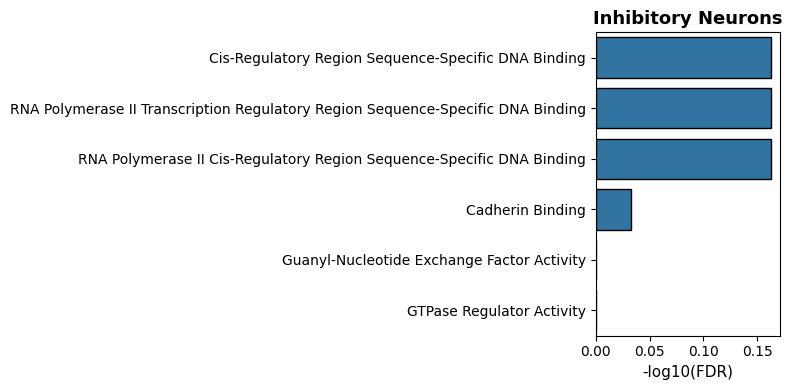

  Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure2/PathwayAnalysis_GSEA/In_gsea_plot_filtered.png

Running GSEA pathway analysis for: Mic


2025-08-05 20:12:48,847 [WARNING] Duplicated values found in preranked stats: 19.31% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-08-05 20:12:48,849 [INFO] Parsing data files for GSEA.............................
2025-08-05 20:12:48,851 [INFO] Enrichr library gene sets already downloaded in: /home/adm808/.cache/gseapy, use local file
2025-08-05 20:12:48,867 [INFO] 1080 gene_sets have been filtered out when max_size=1000 and min_size=5
2025-08-05 20:12:48,869 [INFO] 0067 gene_sets used for further statistical testing.....
2025-08-05 20:12:48,870 [INFO] Start to run GSEA...Might take a while..................
2025-08-05 20:12:49,078 [INFO] Congratulations. GSEApy runs successfully................



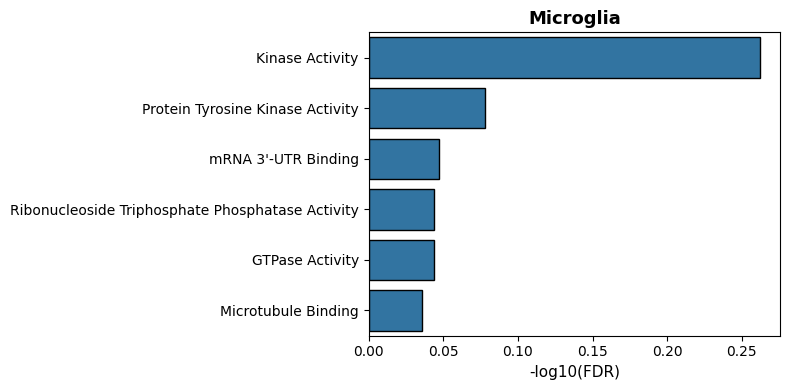

  Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure2/PathwayAnalysis_GSEA/Mic_gsea_plot_filtered.png

Running GSEA pathway analysis for: Oli


2025-08-05 20:12:50,689 [WARNING] Duplicated values found in preranked stats: 0.32% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-08-05 20:12:50,691 [INFO] Parsing data files for GSEA.............................
2025-08-05 20:12:50,692 [INFO] Enrichr library gene sets already downloaded in: /home/adm808/.cache/gseapy, use local file
2025-08-05 20:12:50,710 [INFO] 1068 gene_sets have been filtered out when max_size=1000 and min_size=5
2025-08-05 20:12:50,712 [INFO] 0079 gene_sets used for further statistical testing.....
2025-08-05 20:12:50,713 [INFO] Start to run GSEA...Might take a while..................
2025-08-05 20:12:50,988 [INFO] Congratulations. GSEApy runs successfully................



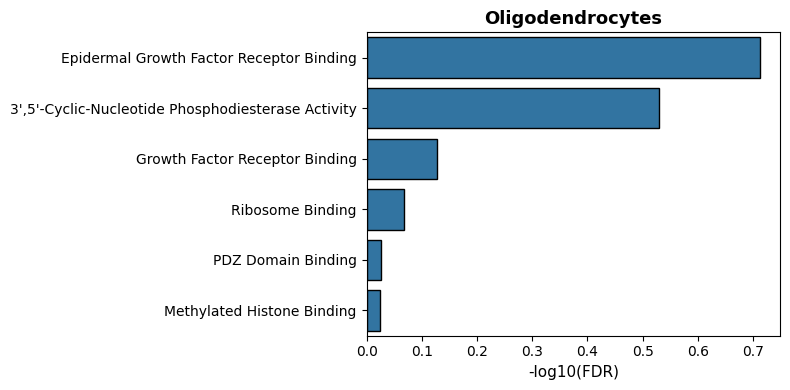

  Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure2/PathwayAnalysis_GSEA/Oli_gsea_plot_filtered.png

Running GSEA pathway analysis for: Opc


2025-08-05 20:12:52,916 [WARNING] Duplicated values found in preranked stats: 58.92% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-08-05 20:12:52,917 [INFO] Parsing data files for GSEA.............................
2025-08-05 20:12:52,919 [INFO] Enrichr library gene sets already downloaded in: /home/adm808/.cache/gseapy, use local file
2025-08-05 20:12:52,937 [INFO] 1045 gene_sets have been filtered out when max_size=1000 and min_size=5
2025-08-05 20:12:52,939 [INFO] 0102 gene_sets used for further statistical testing.....
2025-08-05 20:12:52,940 [INFO] Start to run GSEA...Might take a while..................
2025-08-05 20:12:53,392 [INFO] Congratulations. GSEApy runs successfully................



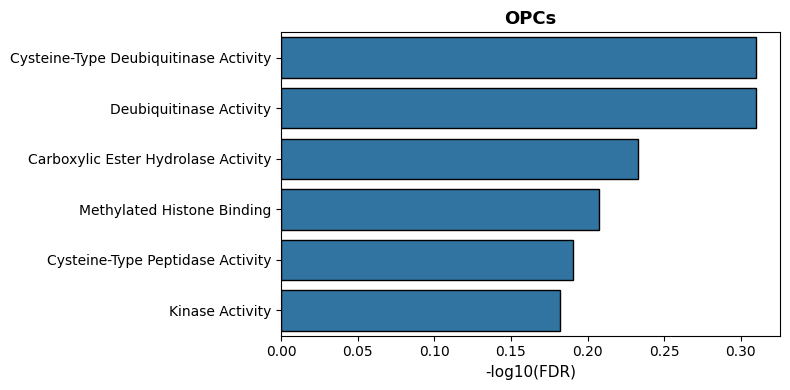

  Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure2/PathwayAnalysis_GSEA/Opc_gsea_plot_filtered.png


In [34]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from gseapy import prerank

# === Setup ===
output_dir = '/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure2/'
pathway_dir = os.path.join(output_dir, "PathwayAnalysis_GSEA")
os.makedirs(pathway_dir, exist_ok=True)

ct_labels = {
    'Ast': 'Astrocytes',
    'Ex': 'Excitatory Neurons',
    'In': 'Inhibitory Neurons',
    'Mic': 'Microglia',
    'Oli': 'Oligodendrocytes',
    'Opc': 'OPCs'
}

base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new"
gene_matrix = pd.read_parquet('/home/adm808/NormalizedCellMatrixSyn18485175.parquet')
background_genes = set(gene_matrix.index.str.upper())
print(f"Total background genes: {len(background_genes)}")

# === Stylized plot ===
def plot_pathways_gsea(df, title, save_path, top_n=6, color="#1f78b4"):
    df = df.copy()
    df = df[df["fdr"].notna()]
    df = df[pd.to_numeric(df["fdr"], errors="coerce").notna()]
    df = df.sort_values("fdr", ascending=True).head(top_n)

    if df.empty:
        print(f"  No enriched terms for {title}")
        return

    df["name"] = (
        df["Term"]
        .str.replace(r"^GO_Molecular_Function_2023__", "", regex=True)  # Remove prefix with underscores
        .str.replace(r"\s*\(GO:\d+\)", "", regex=True)                  # Remove suffix like (GO:0001234)
        .str.replace("_", " ")                                          # Replace underscores with spaces
        .str.strip()
    )

    df["-log10(FDR)"] = -np.log10(df["fdr"].astype(float))

    plt.figure(figsize=(8, 4))
    sns.barplot(
        x="-log10(FDR)",
        y="name",
        data=df,
        color=color,
        edgecolor="black"
    )
    plt.title(title, fontsize=13, fontweight="bold")
    plt.xlabel("-log10(FDR)", fontsize=11)
    plt.ylabel("")
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    # plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(save_path, dpi=600)
    plt.show()
    print(f"  Saved: {save_path}")

# === GSEA Pathway Analysis Loop ===
for cell_type in ct_labels.keys():
    print(f"\nRunning GSEA pathway analysis for: {cell_type}")
    norm_feature_scores = {}

    for split in range(1, 6):
        joblib_path = os.path.join(base_dir, cell_type, f"split_{split}", "maximal_classifier.joblib")
        if not os.path.exists(joblib_path):
            print(f"  Warning: Missing split {split} for {cell_type}")
            continue

        model = joblib.load(joblib_path)
        feature_names = model.feature_names_in_
        importances = model.feature_importances_

        imp_dict = dict(zip(feature_names, importances))
        total_nonzero = np.sum([v for v in imp_dict.values() if v > 0])

        for feature in feature_names:
            raw_imp = imp_dict.get(feature, 0.0)
            if raw_imp > 0 and total_nonzero > 0:
                norm_imp = raw_imp / total_nonzero
            else:
                norm_imp = 0.0
            norm_feature_scores.setdefault(feature.upper(), []).append(norm_imp)

    # === Score: Mean normalized importance across splits ===
    ranked_genes = {
        gene: np.mean(imps)
        for gene, imps in norm_feature_scores.items()
        if np.count_nonzero(imps) >= 2
    }

    if len(ranked_genes) < 10:
        print(f"  Too few predictive genes with consistent normalized importance for {cell_type}. Skipping.")
        continue

    # === Write .rnk ===
    rnk_df = pd.DataFrame(ranked_genes.items(), columns=["gene_name", "score"])
    rnk_df["gene_name"] = rnk_df["gene_name"].str.upper()
    rnk_df = rnk_df.sort_values("score", ascending=False)
    rnk_path = os.path.join(pathway_dir, f"{cell_type}.rnk")
    rnk_df.to_csv(rnk_path, sep="\t", index=False, header=False, float_format="%.16g")

    # === Run GSEA ===
    pre_res = prerank(
        rnk=rnk_path,
        gene_sets=[
            "GO_Molecular_Function_2023"
            # Add others here if needed
        ],
        background=list(background_genes),
        outdir=None,
        seed=0,
        verbose=True,
        min_size=5,
        max_size=1000
    )

    # === Save and plot
    gsea_df_full = pre_res.res2d.reset_index().rename(columns={"FDR q-val": "fdr"})
    gsea_df_full.to_csv(os.path.join(pathway_dir, f"{cell_type}_gsea_results_unfiltered.csv"), index=False)

    gsea_df = gsea_df_full  # <- if filtering, change this to filtered version

    plot_pathways_gsea(
        gsea_df,
        title=ct_labels[cell_type],
        save_path=os.path.join(pathway_dir, f"{cell_type}_gsea_plot_filtered.png"),
        top_n=6,
        color="#1f78b4"
    )